**Q1. What is a Common Table Expression (CTE), and how does it improve SQL query readability?**

**solution:**


A Common Table Expression (CTE) is a temporary, named result set that you can reference within a `SELECT`, `INSERT`, `UPDATE`, or `DELETE` statement. You define a CTE using the WITH clause, which precedes the main query.

Here is how CTEs improve SQL query readability and structure:

**1. Improved Logical Structure**

Instead of writing complex, nested subqueries (which can become difficult to follow as they grow deeper), a CTE allows you to break a complex problem into smaller, logical steps. You can define each step as a named CTE, making the final query read more like a set of modular building blocks.

**2. Enhanced Maintainability**

Because each CTE has a clear, descriptive name, it is much easier for others (or your future self) to understand the intent behind a specific part of the data transformation. If you need to debug a specific segment of a complex report, you can isolate and run just the individual CTE query to verify its output.

**3. Ability to Perform Recursion**
A powerful feature of CTEs is the Recursive CTE. This allows a query to reference itself, which is essential for working with hierarchical or tree-structured data (e.g., organizational charts, category trees, or graph paths) that would otherwise be nearly impossible to handle cleanly with standard joins.

**Example**

Imagine you need to calculate the average salary of employees per department, but only for departments with more than 10 employees.

**Without a CTE (Nested Subquery):**

SELECT department_name, avg_salary

FROM (

   SELECT department_id, AVG(salary) as avg_salary

   FROM employees

  GROUP BY department_id

   HAVING COUNT(*) > 10


) AS dept_stats

JOIN departments d ON dept_stats.department_id = d.id;

**With a CTE (Readability Focused):**

WITH LargeDepartments AS (

  Step 1: Identify departments with > 10 employees

   SELECT department_id, AVG(salary) as avg_salary

   FROM employees

 GROUP BY department_id

   HAVING COUNT(*) > 10

)

Step 2: Join the CTE to the main table

SELECT d.department_name, ld.avg_salary

FROM LargeDepartments ld

JOIN departments d ON ld.department_id = d.id;

**Q2. Why are some views updatable while others are read-only? Explain with an example.**

**solution:**


Whether a database view is updatable (meaning you can perform INSERT, UPDATE, or DELETE operations on it) depends on how directly the view maps back to the underlying base table.

The database engine must be able to unambiguously map every row and column in the view back to a specific row and column in the original table. If that mapping is broken or ambiguous, the view becomes read-only.

**Rules for Updatable Views**

In most relational database management systems (RDBMS), a view is updatable if it satisfies these general conditions:

**1. Direct Mapping**: It refers to only one base table.

**2. No Aggregation**: It does not use aggregate functions like SUM(), AVG(), COUNT(), etc.

**3. No Grouping:** It does not use GROUP BY or HAVING clauses.

**4. No Distinct/Set Operators:** It does not use DISTINCT, UNION, or UNION ALL.

**5. No Calculated Columns**: It does not contain columns derived from expressions (e.g., Price * Quantity).

**Example Comparison**

Assume we have a table called Employees:

**1. The Updatable View**

CREATE VIEW SalesEmployees AS

SELECT ID, Name, Salary

FROM Employees

WHERE Department = 'Sales';


**2. The Read-Only View**

This view uses an aggregate function to summarize data.

CREATE VIEW DeptSalaryStats AS

SELECT Department, AVG(Salary) as AvgSalary

FROM Employees

GROUP BY Department;




**Q3. What advantages do stored procedures offer compared to writing raw SQL queries repeatedly?**

**solution:**

Stored procedures are precompiled collections of SQL statements stored directly in the database. They serve as a robust alternative to writing and executing "raw" SQL queries from your application code.

Here are the primary advantages of using stored procedures:

**1. Improved Performance**

**Precompilation:** When you create a stored procedure, the database parses, compiles, and optimizes the execution plan. Subsequent executions are faster because the database skips the compilation phase.

**Reduced Network Traffic:** Instead of sending long, complex strings of raw SQL over the network, your application sends a single, short call (e.g., EXEC GetEmployeeReport;). This significantly reduces the amount of data transmitted between the app and the database.

**2. Enhanced Security**

**SQL Injection Prevention:** Stored procedures use parameters, which treat input as data rather than executable code. This is a highly effective defense against SQL injection attacks.

**Granular Access Control:** You can grant users permission to execute a stored procedure without giving them direct SELECT, INSERT, or DELETE access to the underlying tables. This allows you to restrict data exposure while still enabling necessary operations.

**3. Centralized Business Logic**

**Code Reusability:** If the logic to calculate a "Monthly Tax" or "Employee Bonus" is stored as a procedure, it can be called by multiple applications (e.g., a web portal, a mobile app, and an internal reporting tool) consistently.

**Simplified Maintenance:** If business rules change, you only need to update the logic in the stored procedure on the database server. You do not need to hunt through multiple application codebases to deploy updates.

**4. Transactional Integrity**

**Batching Operations:** Stored procedures allow you to bundle multiple SQL statements into a single transaction. This ensures that all operations succeed or fail together, maintaining data consistency without requiring complex logic in your application layer.

**Q4. What is the purpose of triggers in a database? Mention one use case where a trigger is essential.**

**solution:**

A trigger is a set of instructions that automatically executes in response to specific events (like INSERT, UPDATE, or DELETE) on a particular table.

**Essential Use Case: Audit Logging.** When a sensitive record is deleted or changed, a trigger can automatically capture the old data and a timestamp into an archive table. This ensures a permanent trail for security and compliance that cannot be bypassed by manual edits.

**Q5. Explain the need for data modelling and normalization when designing a database.**

**solution:**

* **Data Modeling:** This is the blueprint phase. It ensures that the database accurately reflects the business requirements and that relationships between different entities (like Products and Sales) are logically mapped.

* **Normalization:** This is the process of organizing data to reduce redundancy and improve data integrity. By splitting data into related tables, you prevent "update anomalies" (where you change a value in one place but forget another) and ensure that each piece of data is stored in exactly one logical location.

**Dataset (Use for Q6–Q9)**

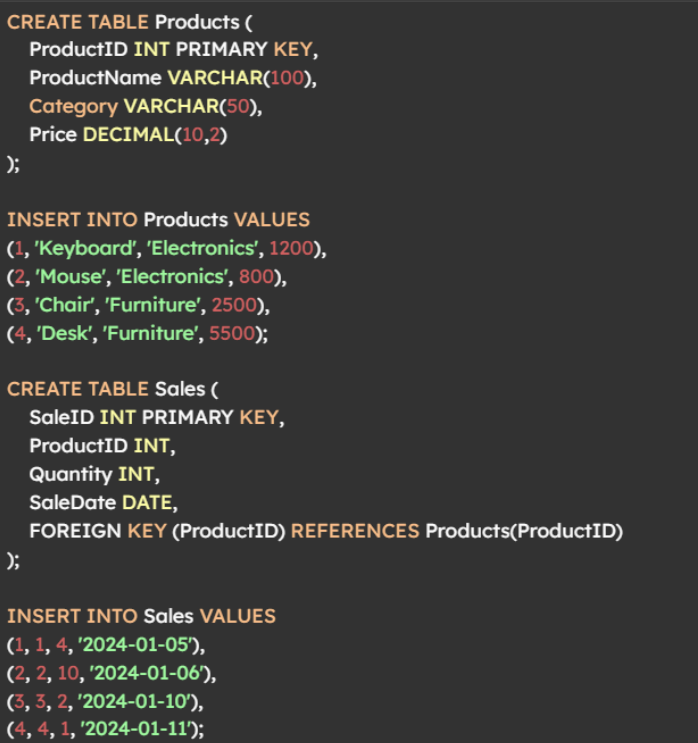**

**Q6. Write a CTE to calculate the total revenue for each product**
 **(Revenues = Price × Quantity)**, **and return only products where  revenue > 3000.**

**solution:**

WITH ProductRevenue AS (

   SELECT

   p.ProductName,

  (p.Price * s.Quantity) AS Revenue

  FROM Products p

  JOIN Sales s ON p.ProductID = s.ProductID

)

SELECT * FROM ProductRevenue

WHERE Revenue > 3000;

**Q7. Create a view named vw_categorysummary that shows:**

**Category, TotalProducts, AveragePrice.**

**solution:**


CREATE VIEW vw_CategorySummary As

SELECT

   Category,

  COUNT(ProductID) AS TotalProducts,

  AVG(Price) AS AveragePrice

FROM Products

GROUP BY Category;

**Q8.Create an updatable view containing ProductID, ProductName, and Price.**
 **Then update the price of ProductID = 1 using the view.**

 **solution:**

-- Creating the view

CREATE VIEW vw_ProductBasic AS

SELECT ProductID, ProductName, Price

FROM Products;

-- Updating through the view

UPDATE vw_ProductBasic

SET Price = 1300 -- Example new price

WHERE ProductID = 1;

**Q9.Create a stored procedure that accepts a category name and returns all products belonging to that category.**

**solution:**

CREATE PROCEDURE GetProductsByCategory (IN cat_name VARCHAR(50))

BEGIN

  SELECT * FROM Products

  WHERE Category = cat_name;
  
END;

**Q10.Create an AFTER DELETE trigger on the products table that archives deleted product rows into a new table productarchive. The archive should store ProductID, ProductName, Category, Price, and DeletedAt timestamp.**

**solution**:

-- First, create the archive table


CREATE TABLE ProductArchive (

  ProductID INT,

  ProductName VARCHAR(100),

  Category VARCHAR(50),

  Price DECIMAL(10,2),

  DeletedAt TIMESTAMP DEFAULT CURRENT_TIMESTAMP

);

-- Create the trigger


CREATE TRIGGER tr_AfterProductDelete

AFTER DELETE ON Products

FOR EACH ROW

BEGIN

  INSERT INTO ProductArchive (ProductID, ProductName, Category, Price)

  VALUES (OLD.ProductID, OLD.ProductName, OLD.Category, OLD.Price);

END;